# Analyse Factorielle des Correspondances (AFC)
## Domaines professionnels × Compétences — LinkedIn 2023–2024

---

### Objectif

> **Quelles compétences sont typiques de quels domaines professionnels ?**

L'AFC est une méthode statistique qui permet de voir les liens entre deux variables qualitatives.  
Le résultat est un graphique appelé **biplot**, où les domaines et les compétences sont placés ensemble.

### Pourquoi regrouper en domaines ?

Les données LinkedIn contiennent beaucoup de titres de postes différents.  
Analyser chaque titre séparément crée deux problèmes :

- Certains postes ont **beaucoup plus d'offres** que d'autres → le graphique est déséquilibré.
- Des postes très différents (ex : infirmier et data scientist) **n'ont aucune compétence en commun** → les axes captent surtout cette différence extrême, et les nuances entre les métiers proches deviennent invisibles.

On regroupe donc les titres en **6 domaines homogènes** : chaque domaine contient des métiers qui ont des compétences similaires.

### Plan
1. Chargement et échantillonnage
2. Regroupement en domaines
3. Tableau de contingence
4. Fréquences relatives et marges
5. Profils lignes et colonnes
6. Test du χ² et inertie totale
7. Matrice des résidus standardisés Z
8. Décomposition SVD
9. Scree Plot
10. Qualité de représentation (cos²)
11. Contributions (CTR)
12. Biplot final
13. Résumé et limites

---
## Étape 0 — Imports

In [36]:
import pandas as pd              # pandas : bibliothèque pour manipuler des tableaux de données (DataFrames)
import numpy as np               # numpy : calculs numériques (matrices, racines carrées, SVD, etc.)
import matplotlib.pyplot as plt  # matplotlib : tracer des graphiques (barres, courbes, nuages de points)
import matplotlib.patches as mpatches  # mpatches : créer des éléments de légende personnalisés (rectangles colorés)
from scipy.stats import chi2_contingency  # chi2_contingency : test du χ² — mesure si deux variables sont liées ou indépendantes
from IPython.display import display       # display : affiche les DataFrames en HTML dans Jupyter (plus lisible que print)

SEED = 42            # valeur fixe pour le générateur aléatoire — garantit que les résultats sont reproductibles
np.random.seed(SEED) # fixe le générateur aléatoire de numpy avec cette valeur — tout tirage aléatoire donnera le même résultat

# Couleurs du rapport — définies une seule fois ici pour être utilisées dans tous les graphiques
MARINE = '#12345F'  # bleu marine — couleur des domaines professionnels sur le biplot
ORANGE = '#DC641E'  # orange     — couleur des compétences sur le biplot
GRIS   = '#AAAAAA'  # gris clair — couleur des points mal représentés (cos² faible)


---
## Étape 1 — Chargement et échantillonnage

On charge les trois fichiers et on les fusionne en un seul tableau.  
Chaque ligne du résultat est un couple **(offre, compétence)** :  
si une offre demande 5 compétences, elle apparaît 5 fois dans le tableau.

On utilise `sample(random_state=42)` pour un tirage **aléatoire et reproductible** :  
tout le monde obtient les mêmes résultats en réexécutant le notebook.  
On évite de prendre les premières lignes car les données sont souvent triées par date ou région — l'échantillon ne serait pas représentatif.

In [37]:
# pd.read_csv() lit un fichier CSV depuis le disque et le transforme en DataFrame pandas
postings   = pd.read_csv('../data/raw/postings.csv')    # offres d'emploi LinkedIn : job_id, titre du poste, localisation, etc.
job_skills = pd.read_csv('../data/raw/job_skills.csv')  # liens entre offres et compétences : job_id + skill_abr (code de compétence)
skills     = pd.read_csv('../data/raw/skills.csv')      # table de référence : skill_abr (code) → skill_name (nom complet)

# len() retourne le nombre de lignes du DataFrame
print(f"postings   : {len(postings):,} lignes")
print(f"job_skills : {len(job_skills):,} lignes")
# .nunique() compte le nombre de valeurs différentes dans une colonne
print(f"skills     : {len(skills):,} lignes ({skills['skill_name'].nunique()} compétences uniques)")

# min() choisit la plus petite valeur : on prend tout le fichier si < 500 000 lignes, sinon on limite
N_SAMPLE = min(500_000, len(postings))
# .sample(n=...) tire aléatoirement N lignes — random_state=SEED garantit le même tirage à chaque exécution
postings_sample = postings.sample(n=N_SAMPLE, random_state=SEED)

# Fusion en chaîne : on part de l'échantillon, on lui ajoute les compétences, puis les noms lisibles
# [[ 'job_id', 'title' ]] : on ne garde que ces deux colonnes de postings pour alléger le tableau
# .merge(job_skills, on='job_id') : jointure sur job_id — une offre peut avoir plusieurs compétences → plusieurs lignes
# .merge(skills, on='skill_abr') : jointure sur le code compétence → ajoute le nom complet (skill_name)
df = (postings_sample[['job_id', 'title']]
      .merge(job_skills, on='job_id')
      .merge(skills,     on='skill_abr'))

print(f"Tableau fusionné : {len(df):,} lignes × {df.shape[1]} colonnes")
df.head()  # affiche les 5 premières lignes pour vérifier le résultat de la fusion


postings   : 123,849 lignes
job_skills : 213,768 lignes
skills     : 35 lignes (35 compétences uniques)
Tableau fusionné : 205,778 lignes × 4 colonnes


,job_id,title,skill_abr,skill_name
0,3902944011,Senior Automation Engineer - Power Systems,ENG,Engineering
1,3902944011,Senior Automation Engineer - Power Systems,IT,Information Technology
2,3901960222,DISH Installation Technician - Field,ENG,Engineering
3,3901960222,DISH Installation Technician - Field,IT,Information Technology
4,3900944095,Order Builder,MGMT,Management


---
## Étape 2 — Regroupement en 6 domaines homogènes

### Pourquoi l'homogénéité des domaines est importante

Un domaine est **homogène** quand tous les métiers qu'il contient partagent des compétences similaires.  
Si on mélange des métiers très différents dans le même domaine, deux choses se passent :

- Le profil moyen du domaine ne ressemble à **aucun** des métiers réels — c'est une moyenne artificielle.
- L'information du domaine se disperse sur beaucoup d'axes, ce qui donne un **cos² faible** : le point est mal représenté sur le biplot.

**Exemple du problème précédent :** le domaine « Opérations » regroupait `infirmier`, `avocat`, `supply chain` et `RH`.  
Ces métiers n'ont presque aucune compétence en commun. Le résultat : le point « Opérations » se retrouvait au centre du graphique, impossible à interpréter.

### La solution : 6 domaines cohérents

On garde uniquement les métiers qui ont un **profil de compétences comparable**.
Les métiers sans lien avec les autres (infirmier, avocat, logistique) sont **exclus** de l'analyse.  
Cela améliore la qualité de la représentation et rend le biplot interprétable.

| Domaine | Métiers inclus | Compétences communes attendues |
|---|---|---|
| **Tech & Ingénierie** | Software Engineer, DevOps, Cloud, Security | Programmation, architecture système |
| **Data & Analyse** | Data Scientist, Data Analyst, Data Engineer | Python, SQL, machine learning |
| **Gestion de Projet** | Project Manager, Product Manager, Scrum Master | Planification, Agile, communication |
| **Commerce & Marketing** | Sales Manager, Account Manager, Marketing | CRM, négociation, relation client |
| **Finance & Compta** | Financial Analyst, Accountant, Auditor | Comptabilité, analyse financière |
| **RH & Recrutement** | HR Manager, Recruiter, Talent Acquisition | Recrutement, gestion des talents |

In [38]:
# DOMAINES est un dictionnaire : clé = mot-clé à chercher dans le titre, valeur = nom du domaine
# On choisit des mots-clés spécifiques pour éviter d'affecter un titre au mauvais domaine
DOMAINES = {
    # Tech & Ingénierie : métiers de développement et infrastructure
    'software engineer' : 'Tech & Ingénierie',
    'software developer': 'Tech & Ingénierie',
    'full stack'        : 'Tech & Ingénierie',
    'frontend'          : 'Tech & Ingénierie',
    'backend'           : 'Tech & Ingénierie',
    'devops'            : 'Tech & Ingénierie',
    'cloud engineer'    : 'Tech & Ingénierie',
    'security engineer' : 'Tech & Ingénierie',
    'cybersecurity'     : 'Tech & Ingénierie',

    # Data & Analyse : métiers de la donnée et de l'IA
    'data scientist'    : 'Data & Analyse',
    'machine learning'  : 'Data & Analyse',
    'data analyst'      : 'Data & Analyse',
    'business analyst'  : 'Data & Analyse',
    'data engineer'     : 'Data & Analyse',

    # Gestion de Projet : métiers de pilotage et coordination
    'project manager'   : 'Gestion de Projet',
    'program manager'   : 'Gestion de Projet',
    'product manager'   : 'Gestion de Projet',
    'product owner'     : 'Gestion de Projet',
    'scrum master'      : 'Gestion de Projet',

    # Commerce & Marketing : métiers de la vente et communication
    'sales manager'       : 'Commerce & Marketing',
    'account manager'     : 'Commerce & Marketing',
    'marketing manager'   : 'Commerce & Marketing',
    'business development': 'Commerce & Marketing',

    # Finance & Compta : métiers financiers et comptables
    'financial analyst' : 'Finance & Compta',
    'accountant'        : 'Finance & Compta',
    'auditor'           : 'Finance & Compta',
    'finance manager'   : 'Finance & Compta',

    # RH & Recrutement : métiers des ressources humaines uniquement
    # On exclut supply chain, logistique, infirmier, avocat
    # car ils ont des profils de compétences sans rapport avec les RH.
    'hr manager'          : 'RH & Recrutement',
    'human resource'      : 'RH & Recrutement',
    'recruiter'           : 'RH & Recrutement',
    'talent acquisition'  : 'RH & Recrutement',
    'people operations'   : 'RH & Recrutement',
}

def mapper_domaine(titre):
    """Retourne le domaine correspondant au titre, ou None si non reconnu."""
    t = str(titre).lower()  # str() convertit en texte au cas où la valeur est NaN — .lower() met en minuscules pour comparer sans tenir compte de la casse
    for mot_cle, domaine in DOMAINES.items():  # on parcourt tous les mots-clés du dictionnaire
        if mot_cle in t:   # si le mot-clé est contenu dans le titre, on retourne le domaine
            return domaine
    return None  # si aucun mot-clé ne correspond, on retourne None (le titre sera exclu)

# .apply(mapper_domaine) applique la fonction à chaque valeur de la colonne title
# → crée une nouvelle colonne 'domaine' avec le résultat pour chaque ligne
df['domaine'] = df['title'].apply(mapper_domaine)

# .dropna(subset=['domaine']) supprime toutes les lignes où 'domaine' est None
# ce sont les titres qui ne correspondaient à aucun mot-clé du dictionnaire
df = df.dropna(subset=['domaine'])
display(df.head())

print("Nombre d'offres uniques par domaine :")
# .groupby('domaine')['job_id'].nunique() : pour chaque domaine, compte le nombre d'offres distinctes
# .sort_values(ascending=False) : trie du plus grand au plus petit
dist = df.groupby('domaine')['job_id'].nunique().sort_values(ascending=False)
for domaine, effectif in dist.items():  # on parcourt chaque (domaine, effectif) du résultat
    barre  = '█' * (effectif // 200)  # barre de progression : 1 bloc = 200 offres
    statut = 'ok' if effectif >= 200 else ' Trop petit'  # alerte si le domaine a trop peu d'offres
    print(f"  {domaine:<25} {effectif:>5,}  {barre} {statut}")  # :<25 aligne à gauche sur 25 chars, :>5, formate avec séparateur des milliers


,job_id,title,skill_abr,skill_name,domaine
10,3901967275,Human Resources Project Manager,PRJM,Project Management,Gestion de Projet
11,3901967275,Human Resources Project Manager,IT,Information Technology,Gestion de Projet
18,3901947295,Laboratory Operations (LabOps) Project Manager,PRJM,Project Management,Gestion de Projet
19,3901947295,Laboratory Operations (LabOps) Project Manager,IT,Information Technology,Gestion de Projet
25,3904585602,Staff Accountant to $55K with company paid chi...,ACCT,Accounting/Auditing,Finance & Compta


Nombre d'offres uniques par domaine :
  Commerce & Marketing      3,515  █████████████████ ok
  Gestion de Projet         3,344  ████████████████ ok
  Tech & Ingénierie         2,673  █████████████ ok
  Finance & Compta          2,056  ██████████ ok
  Data & Analyse            1,689  ████████ ok
  RH & Recrutement          1,099  █████ ok


### Ce qu'on vérifie ici

Chaque domaine doit avoir **au moins 200 offres uniques**.  
Si un groupe est trop petit, ses proportions ne sont pas stables — un petit changement dans les données modifierait beaucoup sa position sur le graphique.  
Un domaine insuffisant doit être exclu ou fusionné avec un domaine proche.

---
## Étape 3 — Tableau de contingence

C'est la **matrice de départ** de toute AFC.  
Chaque case $n_{ij}$ contient le nombre de fois où la compétence $j$ apparaît dans les offres du domaine $i$.

$$n_{ij} = \text{nombre d'offres du domaine } i \text{ mentionnant la compétence } j$$

Un domaine avec beaucoup d'offres aura mécaniquement des chiffres plus élevés partout, même si ses proportions ne sont pas remarquables.  
C'est ce biais que l'AFC corrige à l'étape suivante en passant aux fréquences relatives.

In [39]:
# pd.crosstab() construit le tableau de contingence directement depuis les colonnes
# ligne = domaine, colonne = compétence, valeur = nombre de fois que la compétence apparaît dans ce domaine
contingence = pd.crosstab(df['domaine'], df['skill_name'])

# Sécurité : on supprime les lignes/colonnes dont la somme est nulle (domaines ou compétences sans aucune observation)
# .sum(axis=1) : somme par ligne (un total par domaine)
# .sum(axis=0) : somme par colonne (un total par compétence)
# > 0 : garde seulement les lignes/colonnes qui ont au moins une observation
contingence = contingence.loc[
    contingence.sum(axis=1) > 0,
    contingence.sum(axis=0) > 0
]

n = int(contingence.values.sum())  # effectif total n = somme de toutes les cases du tableau
                                    # .values retourne le tableau numpy sous-jacent — .sum() additionne tout
                                    # int() convertit le résultat en entier (pas de décimales)

print(f"Dimensions : {contingence.shape[0]} domaines × {contingence.shape[1]} compétences")
print(f"Effectif total n = {n:,}")
print()

# Ajout des totaux marginaux pour l'affichage
ct_aff = contingence.copy()  # .copy() crée une copie indépendante pour ne pas modifier contingence
ct_aff.loc['TOTAL'] = ct_aff.sum(axis=0)  # .loc['TOTAL'] ajoute une nouvelle ligne avec les totaux par colonne
ct_aff['TOTAL']     = ct_aff.sum(axis=1)  # ajoute une nouvelle colonne avec les totaux par ligne

# .style permet d'appliquer un formatage HTML au DataFrame pour Jupyter
# .background_gradient() colore les cases selon leur valeur (cmap='Blues' : plus c'est foncé, plus c'est élevé)
# subset= limite le dégradé aux cases du tableau original (sans les totaux)
# pd.IndexSlice[lignes, colonnes] permet de sélectionner une sous-région du tableau
# .format('{:,.0f}') : formate les nombres avec séparateur des milliers, sans décimales
# .set_caption() ajoute un titre en italique au-dessus du tableau
display(
    ct_aff.style
    .background_gradient(cmap='Blues',
                         subset=pd.IndexSlice[contingence.index, contingence.columns])
    .format('{:,.0f}')
    .set_caption("Tableau de contingence nij — domaines × compétences (avec totaux marginaux)")
)


Dimensions : 6 domaines × 35 compétences
Effectif total n = 25,955



skill_name,Accounting/Auditing,Administrative,Advertising,Analyst,Art/Creative,Business Development,Consulting,Customer Service,Design,Distribution,Education,Engineering,Finance,General Business,Health Care Provider,Human Resources,Information Technology,Legal,Management,Manufacturing,Marketing,Other,Product Management,Production,Project Management,Public Relations,Purchasing,Quality Assurance,Research,Sales,Science,Strategy/Planning,Supply Chain,Training,Writing/Editing,TOTAL
domaine,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Commerce & Marketing,14,39,54,10,2,"2,527",58,112,5,13,3,18,51,40,13,8,51,7,129,37,452,75,40,2,31,12,2,1,7,"3,021",7,41,12,9,3,"6,906"
Data & Analyse,9,15,5,491,0,73,31,4,3,0,1,403,36,16,5,9,"1,286",2,16,5,16,66,20,1,24,0,0,19,315,55,16,24,3,2,0,"2,971"
Finance & Compta,"1,520",40,1,137,1,5,19,3,1,0,2,9,"1,380",26,12,6,59,4,71,68,0,36,0,4,18,0,2,21,3,267,2,17,1,1,0,"3,736"
Gestion de Projet,12,51,12,37,10,52,97,16,52,5,4,288,28,16,17,23,"1,786",7,194,64,422,90,586,21,"2,051",6,3,67,15,44,23,63,25,10,4,"6,201"
RH & Recrutement,5,94,4,7,1,39,20,35,1,0,7,7,5,14,10,948,24,9,36,12,7,44,0,1,13,1,0,1,3,64,1,14,0,16,0,"1,443"
Tech & Ingénierie,7,6,6,129,5,10,58,2,24,0,4,"1,842",36,8,2,7,"2,223",2,30,15,10,63,11,1,7,5,0,15,129,14,12,7,1,1,6,"4,698"
TOTAL,"1,567",245,82,811,19,"2,706",283,172,86,18,21,"2,567","1,536",120,59,"1,001","5,429",31,476,201,907,374,657,30,"2,144",24,7,124,472,"3,465",61,166,42,39,13,"25,955"


### Comment lire ce tableau

Les cases les plus sombres indiquent les couples domaine–compétence les plus fréquents.  
Mais une case foncée peut simplement refléter un domaine avec beaucoup d'offres.  
Pour comparer les domaines de façon juste, on passe aux **fréquences relatives** à l'étape suivante.

---
## Étape 4 — Fréquences relatives et marges

On divise chaque case par l'effectif total $n$ pour obtenir des proportions.  
Cela permet de comparer les domaines de façon juste, même si leur taille est différente.

$$f_{ij} = \frac{n_{ij}}{n}$$

Les **marges** sont les sommes par ligne et par colonne :

$$r_i = \sum_j f_{ij} \quad \text{(poids du domaine } i \text{)} \qquad
c_j = \sum_i f_{ij} \quad \text{(poids de la compétence } j \text{)}$$

Ces marges serviront à calculer ce qu'on attendrait si les variables étaient **indépendantes** — c'est-à-dire si le choix d'une compétence ne dépendait pas du domaine.

In [40]:
# On divise chaque case par n pour obtenir les fréquences relatives fij = nij / n
# .values : extrait le tableau numpy du DataFrame (plus rapide pour les calculs matriciels)
# .astype(float) : convertit en nombres décimaux pour que la division soit exacte (pas entière)
F  = contingence.values.astype(float) / n

# .sum(axis=1) : somme chaque ligne → un nombre par domaine — c'est le poids ri du domaine i
ri = F.sum(axis=1)

# .sum(axis=0) : somme chaque colonne → un nombre par compétence — c'est le poids cj de la compétence j
cj = F.sum(axis=0)

# On recrée un DataFrame pandas avec les bons index et colonnes pour l'affichage
F_df  = pd.DataFrame(F, index=contingence.index, columns=contingence.columns)
F_aff = F_df.copy()  # copie pour ne pas modifier F_df qu'on utilisera dans les calculs suivants

F_aff['Marge ri']     = ri                          # ajoute une colonne avec les marges lignes
F_aff.loc['Marge cj'] = list(cj) + [F.sum()]        # ajoute une ligne avec les marges colonnes + somme totale (= 1.0000)
                                                     # list(cj) convertit le tableau numpy en liste Python pour la concaténation

# Affichage avec dégradé de couleur
# .format('{:.4f}') : 4 décimales pour voir les différences entre les petites valeurs
display(
    F_aff.style
    .background_gradient(cmap='Blues',
                         subset=pd.IndexSlice[contingence.index, contingence.columns])
    .format('{:.4f}')
    .set_caption("Fréquences relatives fij = nij / n  (la somme de toutes les cases = 1.0000)")
)

# Vérification : la somme de F doit être exactement 1.0 (à la précision numérique)
print(f"Vérification : somme totale = {F.sum():.4f}  (doit être 1.0000)")


skill_name,Accounting/Auditing,Administrative,Advertising,Analyst,Art/Creative,Business Development,Consulting,Customer Service,Design,Distribution,Education,Engineering,Finance,General Business,Health Care Provider,Human Resources,Information Technology,Legal,Management,Manufacturing,Marketing,Other,Product Management,Production,Project Management,Public Relations,Purchasing,Quality Assurance,Research,Sales,Science,Strategy/Planning,Supply Chain,Training,Writing/Editing,Marge ri
domaine,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Commerce & Marketing,0.0005,0.0015,0.0021,0.0004,0.0001,0.0974,0.0022,0.0043,0.0002,0.0005,0.0001,0.0007,0.0020,0.0015,0.0005,0.0003,0.0020,0.0003,0.0050,0.0014,0.0174,0.0029,0.0015,0.0001,0.0012,0.0005,0.0001,0.0000,0.0003,0.1164,0.0003,0.0016,0.0005,0.0003,0.0001,0.2661
Data & Analyse,0.0003,0.0006,0.0002,0.0189,0.0000,0.0028,0.0012,0.0002,0.0001,0.0000,0.0000,0.0155,0.0014,0.0006,0.0002,0.0003,0.0495,0.0001,0.0006,0.0002,0.0006,0.0025,0.0008,0.0000,0.0009,0.0000,0.0000,0.0007,0.0121,0.0021,0.0006,0.0009,0.0001,0.0001,0.0000,0.1145
Finance & Compta,0.0586,0.0015,0.0000,0.0053,0.0000,0.0002,0.0007,0.0001,0.0000,0.0000,0.0001,0.0003,0.0532,0.0010,0.0005,0.0002,0.0023,0.0002,0.0027,0.0026,0.0000,0.0014,0.0000,0.0002,0.0007,0.0000,0.0001,0.0008,0.0001,0.0103,0.0001,0.0007,0.0000,0.0000,0.0000,0.1439
Gestion de Projet,0.0005,0.0020,0.0005,0.0014,0.0004,0.0020,0.0037,0.0006,0.0020,0.0002,0.0002,0.0111,0.0011,0.0006,0.0007,0.0009,0.0688,0.0003,0.0075,0.0025,0.0163,0.0035,0.0226,0.0008,0.0790,0.0002,0.0001,0.0026,0.0006,0.0017,0.0009,0.0024,0.0010,0.0004,0.0002,0.2389
RH & Recrutement,0.0002,0.0036,0.0002,0.0003,0.0000,0.0015,0.0008,0.0013,0.0000,0.0000,0.0003,0.0003,0.0002,0.0005,0.0004,0.0365,0.0009,0.0003,0.0014,0.0005,0.0003,0.0017,0.0000,0.0000,0.0005,0.0000,0.0000,0.0000,0.0001,0.0025,0.0000,0.0005,0.0000,0.0006,0.0000,0.0556
Tech & Ingénierie,0.0003,0.0002,0.0002,0.0050,0.0002,0.0004,0.0022,0.0001,0.0009,0.0000,0.0002,0.0710,0.0014,0.0003,0.0001,0.0003,0.0856,0.0001,0.0012,0.0006,0.0004,0.0024,0.0004,0.0000,0.0003,0.0002,0.0000,0.0006,0.0050,0.0005,0.0005,0.0003,0.0000,0.0000,0.0002,0.1810
Marge cj,0.0604,0.0094,0.0032,0.0312,0.0007,0.1043,0.0109,0.0066,0.0033,0.0007,0.0008,0.0989,0.0592,0.0046,0.0023,0.0386,0.2092,0.0012,0.0183,0.0077,0.0349,0.0144,0.0253,0.0012,0.0826,0.0009,0.0003,0.0048,0.0182,0.1335,0.0024,0.0064,0.0016,0.0015,0.0005,1.0000


Vérification : somme totale = 1.0000  (doit être 1.0000)


### Ce qu'on obtient

La marge $r_i$ d'un domaine représente sa part dans toutes les observations.  
Par exemple, $r_i = 0.30$ signifie que ce domaine produit 30% de tous les couples offre–compétence.

La marge $c_j$ d'une compétence représente sa fréquence générale dans les offres.  
Une compétence avec $c_j = 0.20$ est mentionnée dans 20% de toutes les associations observées.

---
## Étape 5 — Profils lignes et colonnes

Le **profil ligne** d'un domaine $i$ montre comment ses offres se répartissent entre les compétences :

$$\text{profil ligne}_{ij} = \frac{f_{ij}}{r_i}$$

Chaque ligne du tableau des profils somme à 1.  

Le **profil moyen** est la marge colonne $c_j$ : c'est le profil d'un domaine fictif qui aurait exactement la répartition moyenne de toutes les offres.  
L'AFC mesure l'**écart de chaque profil réel par rapport à ce profil moyen**. Plus l'écart est grand, plus le domaine a un profil original.

In [41]:
# Profils lignes : fij / ri
# .div(ri, axis=0) divise chaque ligne i par ri — axis=0 signifie qu'on divise ligne par ligne
# résultat : chaque ligne représente la répartition des compétences pour un domaine donné, somme = 1
profils_lignes = F_df.div(ri, axis=0)

# Le profil moyen est simplement cj : c'est comme si toutes les lignes avaient le même profil
# pd.DataFrame([cj], ...) crée un DataFrame d'une seule ligne avec les valeurs de cj
profil_moyen = pd.DataFrame([cj], index=['Profil moyen (cj)'], columns=contingence.columns)

# pd.concat() empile verticalement deux DataFrames
# résultat : tableau des profils + ligne du profil moyen
profils_aff = pd.concat([profils_lignes, profil_moyen])

# cmap='RdYlGn' : dégradé rouge → jaune → vert
# rouge = valeur basse = compétence sous-représentée dans ce domaine vs le profil moyen
# vert  = valeur haute = compétence sur-représentée dans ce domaine
display(
    profils_aff.style
    .background_gradient(cmap='RdYlGn')
    .format('{:.3f}')
    .set_caption("Profils lignes fij/ri — Vert = sur-représenté vs profil moyen, Rouge = sous-représenté")
)

print(f"Vérification : chaque ligne de domaine doit sommer à 1.000")
# .sum(axis=1) : somme chaque ligne — doit donner 1.000 pour chaque domaine
# .round(3) : arrondit à 3 décimales
# .to_frame('Somme') : transforme la Series en DataFrame avec la colonne 'Somme'
# .T : transpose pour afficher les domaines en colonnes (plus compact)
print(profils_lignes.sum(axis=1).round(3).to_frame('Somme').T.to_string())


skill_name,Accounting/Auditing,Administrative,Advertising,Analyst,Art/Creative,Business Development,Consulting,Customer Service,Design,Distribution,Education,Engineering,Finance,General Business,Health Care Provider,Human Resources,Information Technology,Legal,Management,Manufacturing,Marketing,Other,Product Management,Production,Project Management,Public Relations,Purchasing,Quality Assurance,Research,Sales,Science,Strategy/Planning,Supply Chain,Training,Writing/Editing
Commerce & Marketing,0.002,0.006,0.008,0.001,0.000,0.366,0.008,0.016,0.001,0.002,0.000,0.003,0.007,0.006,0.002,0.001,0.007,0.001,0.019,0.005,0.065,0.011,0.006,0.000,0.004,0.002,0.000,0.000,0.001,0.437,0.001,0.006,0.002,0.001,0.000
Data & Analyse,0.003,0.005,0.002,0.165,0.000,0.025,0.010,0.001,0.001,0.000,0.000,0.136,0.012,0.005,0.002,0.003,0.433,0.001,0.005,0.002,0.005,0.022,0.007,0.000,0.008,0.000,0.000,0.006,0.106,0.019,0.005,0.008,0.001,0.001,0.000
Finance & Compta,0.407,0.011,0.000,0.037,0.000,0.001,0.005,0.001,0.000,0.000,0.001,0.002,0.369,0.007,0.003,0.002,0.016,0.001,0.019,0.018,0.000,0.010,0.000,0.001,0.005,0.000,0.001,0.006,0.001,0.071,0.001,0.005,0.000,0.000,0.000
Gestion de Projet,0.002,0.008,0.002,0.006,0.002,0.008,0.016,0.003,0.008,0.001,0.001,0.046,0.005,0.003,0.003,0.004,0.288,0.001,0.031,0.010,0.068,0.015,0.095,0.003,0.331,0.001,0.000,0.011,0.002,0.007,0.004,0.010,0.004,0.002,0.001
RH & Recrutement,0.003,0.065,0.003,0.005,0.001,0.027,0.014,0.024,0.001,0.000,0.005,0.005,0.003,0.010,0.007,0.657,0.017,0.006,0.025,0.008,0.005,0.030,0.000,0.001,0.009,0.001,0.000,0.001,0.002,0.044,0.001,0.010,0.000,0.011,0.000
Tech & Ingénierie,0.001,0.001,0.001,0.027,0.001,0.002,0.012,0.000,0.005,0.000,0.001,0.392,0.008,0.002,0.000,0.001,0.473,0.000,0.006,0.003,0.002,0.013,0.002,0.000,0.001,0.001,0.000,0.003,0.027,0.003,0.003,0.001,0.000,0.000,0.001
Profil moyen (cj),0.060,0.009,0.003,0.031,0.001,0.104,0.011,0.007,0.003,0.001,0.001,0.099,0.059,0.005,0.002,0.039,0.209,0.001,0.018,0.008,0.035,0.014,0.025,0.001,0.083,0.001,0.000,0.005,0.018,0.134,0.002,0.006,0.002,0.002,0.001


Vérification : chaque ligne de domaine doit sommer à 1.000
domaine  Commerce & Marketing  Data & Analyse  Finance & Compta  Gestion de Projet  RH & Recrutement  Tech & Ingénierie
Somme                     1.0             1.0               1.0                1.0               1.0                1.0


### Comment lire ce tableau

- Les cases **vertes** : ce domaine utilise cette compétence plus souvent que la moyenne des autres domaines.
- Les cases **rouges** : cette compétence est moins fréquente dans ce domaine que dans l'ensemble.

Ce tableau donne déjà une idée des associations avant même de tracer le graphique.  
L'AFC va résumer toutes ces informations en deux axes pour créer le biplot.

---
## Étape 6 — Test du χ² et inertie totale

Avant de faire l'AFC, on vérifie que les différences entre profils **ne sont pas dues au hasard**.

Le test du $\chi^2$ compare ce qu'on observe ($n_{ij}$) à ce qu'on attendrait si domaines et compétences étaient complètement indépendants ($e_{ij}$) :

$$e_{ij} = \frac{n_{i\cdot} \times n_{\cdot j}}{n} \qquad
\chi^2 = \sum_{i,j} \frac{(n_{ij} - e_{ij})^2}{e_{ij}}$$

L'**inertie totale** mesure la force globale des associations. C'est la quantité que les axes vont se partager :

$$\mathcal{I} = \frac{\chi^2}{n} \qquad \text{avec} \quad \lambda_1 + \lambda_2 + \cdots + \lambda_k = \mathcal{I}$$

> Si la **p-value < 0.05** → les associations sont réelles, l'AFC est justifiée.  
> Si la **p-value ≥ 0.05** → les différences viennent probablement du hasard, l'AFC n'a pas de sens.

In [42]:
# chi2_contingency() effectue le test du χ² d'indépendance
# Il retourne 4 valeurs qu'on décompresse directement :
# chi2_val : valeur du χ² observée
# p_value  : probabilité d'obtenir cette valeur si les variables étaient indépendantes (< 0.05 = lien significatif)
# dof      : degrés de liberté = (nb_lignes - 1) × (nb_colonnes - 1)
# expected : tableau des effectifs attendus sous l'hypothèse d'indépendance
chi2_val, p_value, dof, expected = chi2_contingency(contingence)

# L'inertie totale est le χ² normalisé : I = χ² / n
# Elle mesure la force globale des associations entre domaines et compétences
inertie_totale = chi2_val / n

print("═" * 55)
print("  RÉSULTATS DU TEST DU χ²")
print("═" * 55)
print(f"  χ²                  = {chi2_val:,.2f}")   # :,.2f = séparateur des milliers + 2 décimales
print(f"  Degrés de liberté   = {dof}")
print(f"  Effectif total n    = {n:,}")
print(f"  Inertie totale I    = {inertie_totale:.4f}")  # plus I est grand, plus les associations sont fortes
print(f"  p-value             = {p_value:.8f}")
print("═" * 55)

# Si p < 0.05 : on rejette l'indépendance → l'AFC est justifiée
if p_value < 0.05:
    print("OK Lien statistiquement significatif (p < 0.05)")
    print("   L'AFC est justifiée.")
else:
    print(" Lien non significatif — l'AFC n'est pas recommandée.")

print()
# Contributions au χ² : (nij - eij)² / eij
# nij = valeur observée, eij = valeur attendue sous indépendance
# Plus la valeur est élevée, plus ce couple domaine–compétence est atypique
contrib    = (contingence.values - expected)**2 / expected
contrib_df = pd.DataFrame(contrib.round(2), index=contingence.index, columns=contingence.columns)
print("Contributions au χ² par case — (nij - eij)² / eij")
# cmap='Reds' : rouge foncé = forte contribution = association très marquée
display(
    contrib_df.style
    .background_gradient(cmap='Reds')
    .format('{:.1f}')
    .set_caption("Plus la valeur est élevée, plus ce couple domaine–compétence s'écarte de l'indépendance")
)


═══════════════════════════════════════════════════════
  RÉSULTATS DU TEST DU χ²
═══════════════════════════════════════════════════════
  χ²                  = 67,617.28
  Degrés de liberté   = 170
  Effectif total n    = 25,955
  Inertie totale I    = 2.6052
  p-value             = 0.00000000
═══════════════════════════════════════════════════════
OK Lien statistiquement significatif (p < 0.05)
   L'AFC est justifiée.

Contributions au χ² par case — (nij - eij)² / eij


skill_name,Accounting/Auditing,Administrative,Advertising,Analyst,Art/Creative,Business Development,Consulting,Customer Service,Design,Distribution,Education,Engineering,Finance,General Business,Health Care Provider,Human Resources,Information Technology,Legal,Management,Manufacturing,Marketing,Other,Product Management,Production,Project Management,Public Relations,Purchasing,Quality Assurance,Research,Sales,Science,Strategy/Planning,Supply Chain,Training,Writing/Editing
domaine,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Commerce & Marketing,389.4,10.5,47.5,196.2,1.9,4535.1,4.0,95.9,14.0,14.1,1.2,647.5,313.1,2.0,0.5,250.6,1344.3,0.2,0.0,5.1,183.9,6.0,104.0,4.5,510.1,4.9,0.0,31.0,112.0,4779.0,5.2,0.2,0.1,0.2,0.1
Data & Analyse,161.8,6.1,2.0,1707.8,2.2,180.9,0.1,12.5,4.8,2.1,0.8,40.5,111.2,0.4,0.5,97.3,710.7,0.7,27.2,14.1,74.3,12.6,40.5,1.7,199.8,2.8,0.8,1.6,1260.6,294.3,11.7,1.3,0.7,1.4,1.5
Finance & Compta,7428.7,0.6,9.9,3.5,1.1,379.6,11.6,19.1,10.5,2.6,0.3,351.7,6074.6,4.4,1.4,132.3,667.9,0.1,0.1,52.8,130.6,5.9,94.6,0.0,273.7,3.5,1.0,0.6,62.1,107.7,5.2,2.0,4.2,3.8,1.9
Gestion de Projet,350.8,1.0,2.9,126.8,6.6,546.7,12.8,15.3,48.1,0.1,0.2,172.5,313.1,5.6,0.6,195.4,184.3,0.0,56.7,5.3,194.5,0.0,1172.7,26.7,4622.6,0.0,1.1,47.1,84.8,742.2,4.9,13.7,22.3,0.1,0.3
RH & Recrutement,77.4,474.3,0.1,32.2,0.0,82.5,1.2,67.7,3.0,1.0,29.1,129.1,75.7,8.1,13.8,14308.3,255.7,30.7,3.4,0.1,37.4,25.9,36.5,0.3,94.6,0.1,0.4,5.0,20.6,85.9,1.7,2.5,2.3,88.2,0.7
Tech & Ingénierie,269.8,33.2,5.3,2.2,0.7,470.0,0.9,27.3,4.6,3.3,0.0,4083.0,210.7,8.7,7.0,167.5,1565.5,2.3,36.6,12.6,144.8,0.3,97.9,3.6,374.2,0.1,1.3,2.5,22.2,599.5,0.1,17.7,5.7,5.2,5.7


### Comment lire le tableau des contributions

Les cases les plus rouges sont celles qui contribuent le plus au χ².  
Ce sont les associations les plus fortes : ces domaines et compétences seront les plus éloignés du centre sur le biplot.  
On peut déjà avoir une idée des résultats finaux en regardant ces cases.

---
## Étape 7 — Matrice des résidus standardisés Z

On mesure l'écart entre ce qu'on observe et ce qu'on attendrait sous indépendance,  
normalisé pour que toutes les cases soient comparables entre elles :

$$Z_{ij} = \frac{f_{ij} - r_i \cdot c_j}{\sqrt{r_i \cdot c_j}}$$

| Valeur de $Z_{ij}$ | Signification |
|---|---|
| $Z_{ij} \gg 0$ | Cette compétence est **sur-représentée** dans ce domaine |
| $Z_{ij} \approx 0$ | Pas d'association particulière |
| $Z_{ij} \ll 0$ | Cette compétence est **sous-représentée** dans ce domaine |

**Vérification :** $\sum_{i,j} Z_{ij}^2 = \mathcal{I}$  
C'est cette matrice $Z$ que la SVD va décomposer à l'étape suivante.

In [43]:
# On transforme ri et cj en matrices 2D pour faire les calculs sur toutes les cases en une seule opération
# ri[:, np.newaxis] : ajoute une dimension → transforme un vecteur (n,) en matrice colonne (n, 1)
# cj[np.newaxis, :] : ajoute une dimension → transforme un vecteur (m,) en matrice ligne (1, m)
ri_col = ri[:, np.newaxis]    # forme : (nb_domaines, 1)
cj_lig = cj[np.newaxis, :]    # forme : (1, nb_compétences)

# Résidus standardisés : Z_ij = (f_ij - r_i × c_j) / sqrt(r_i × c_j)
# Numérateur   : f_ij - ri × cj = écart entre fréquence observée et fréquence attendue sous indépendance
# Dénominateur : sqrt(ri × cj)   = normalisation — rend les valeurs comparables entre elles
# numpy broadcast : ri_col * cj_lig produit automatiquement une matrice (nb_dom × nb_comp)
Z = (F - ri_col * cj_lig) / np.sqrt(ri_col * cj_lig)

# Vérification mathématique : somme(Z²) doit égaler l'inertie totale I (à la précision numérique)
somme_Z2 = (Z**2).sum()
print(f"Vérification : somme(Z²) = {somme_Z2:.6f}  |  Inertie I = {inertie_totale:.6f}")
print(f"Écart = {abs(somme_Z2 - inertie_totale):.2e}  (doit être quasi nul)")  # 2e = notation scientifique
print()

Z_df = pd.DataFrame(Z.round(4), index=contingence.index, columns=contingence.columns)
# cmap='RdBu_r' : dégradé rouge → blanc → bleu
# vmin=-0.4, vmax=0.4 : fixe les bornes du dégradé pour centrer sur 0
# Rouge = Z positif = compétence plus fréquente que prévu = sur-représentation
# Bleu  = Z négatif = compétence moins fréquente que prévu = sous-représentation
# '{:+.4f}' : affiche le signe + ou - devant chaque valeur (4 décimales)
display(
    Z_df.style
    .background_gradient(cmap='RdBu_r', vmin=-0.4, vmax=0.4)
    .format('{:+.4f}')
    .set_caption("Matrice Z des résidus standardisés — Rouge = sur-représenté, Bleu = sous-représenté")
)


Vérification : somme(Z²) = 2.605174  |  Inertie I = 2.605174
Écart = 0.00e+00  (doit être quasi nul)



skill_name,Accounting/Auditing,Administrative,Advertising,Analyst,Art/Creative,Business Development,Consulting,Customer Service,Design,Distribution,Education,Engineering,Finance,General Business,Health Care Provider,Human Resources,Information Technology,Legal,Management,Manufacturing,Marketing,Other,Product Management,Production,Project Management,Public Relations,Purchasing,Quality Assurance,Research,Sales,Science,Strategy/Planning,Supply Chain,Training,Writing/Editing
domaine,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Commerce & Marketing,-0.1225,-0.0201,+0.0428,-0.0870,-0.0084,+0.4180,-0.0124,+0.0608,-0.0232,+0.0233,-0.0068,-0.1579,-0.1098,+0.0089,-0.0042,-0.0983,-0.2276,-0.0027,+0.0013,-0.0140,+0.0842,-0.0153,-0.0633,-0.0131,-0.1402,+0.0138,+0.0006,-0.0346,-0.0657,+0.4291,-0.0142,-0.0030,+0.0015,-0.0027,-0.0015
Data & Analyse,-0.0790,-0.0153,-0.0089,+0.2565,-0.0092,-0.0835,-0.0015,-0.0219,-0.0135,-0.0089,-0.0056,+0.0395,-0.0655,+0.0038,-0.0042,-0.0612,+0.1655,-0.0051,-0.0324,-0.0233,-0.0535,+0.0220,-0.0395,-0.0082,-0.0877,-0.0103,-0.0056,+0.0079,+0.2204,-0.1065,+0.0212,+0.0071,-0.0051,-0.0072,-0.0076
Finance & Compta,+0.5350,+0.0049,-0.0195,+0.0116,-0.0065,-0.1209,-0.0211,-0.0271,-0.0201,-0.0100,-0.0037,-0.1164,+0.4838,+0.0130,+0.0075,-0.0714,-0.1604,-0.0014,+0.0019,+0.0451,-0.0709,-0.0151,-0.0604,-0.0010,-0.1027,-0.0115,+0.0061,+0.0046,-0.0489,-0.0644,-0.0142,-0.0088,-0.0127,-0.0121,-0.0085
Gestion de Projet,-0.1163,-0.0061,-0.0106,-0.0699,+0.0159,-0.1451,+0.0222,-0.0243,+0.0431,+0.0021,-0.0028,-0.0815,-0.1098,-0.0147,+0.0048,-0.0868,+0.0843,-0.0009,+0.0467,+0.0143,+0.0866,+0.0004,+0.2126,+0.0321,+0.4220,+0.0007,+0.0064,+0.0426,-0.0571,-0.1691,+0.0137,+0.0230,+0.0293,+0.0014,+0.0031
RH & Recrutement,-0.0546,+0.1352,-0.0016,-0.0352,-0.0003,-0.0564,+0.0067,+0.0511,-0.0107,-0.0062,+0.0335,-0.0705,-0.0540,+0.0176,+0.0230,+0.7425,-0.0993,+0.0344,+0.0115,+0.0015,-0.0380,+0.0316,-0.0375,-0.0032,-0.0604,-0.0018,-0.0039,-0.0139,-0.0282,-0.0575,-0.0081,+0.0097,-0.0095,+0.0583,-0.0053
Tech & Ingénierie,-0.1020,-0.0357,-0.0142,-0.0091,+0.0052,-0.1346,+0.0059,-0.0324,+0.0133,-0.0112,+0.0006,+0.3966,-0.0901,-0.0183,-0.0165,-0.0803,+0.2456,-0.0095,-0.0376,-0.0220,-0.0747,-0.0035,-0.0614,-0.0118,-0.1201,+0.0020,-0.0070,-0.0098,+0.0293,-0.1520,+0.0018,-0.0261,-0.0149,-0.0142,+0.0148


### Ce qu'on lit dans cette matrice

Les cases **rouges foncées** (Z très positif) : cette compétence est beaucoup plus présente dans ce domaine que dans l'ensemble.  
Les cases **bleues foncées** (Z très négatif) : cette compétence est beaucoup moins présente que ce qu'on attendrait.

Ces couleurs préfigurent directement les positions sur le biplot : les cases rouges correspondent aux domaines et compétences qui seront proches sur le graphique.

---
## Étape 8 — Décomposition SVD et coordonnées factorielles

La SVD (Décomposition en Valeurs Singulières) factorise la matrice $Z$ en trois parties :

$$Z = U \cdot \text{diag}(\sigma) \cdot V^T$$

- $\sigma_k$ : valeurs singulières — plus $\sigma_k$ est grand, plus l'axe $k$ est important
- $\lambda_k = \sigma_k^2$ : valeurs propres = inertie capturée par l'axe $k$
- **Vérification :** $\sum_k \lambda_k = \mathcal{I}$

**Coordonnées — normalisation symétrique**

On applique $\sqrt{\sigma_k}$ des deux côtés (domaines et compétences) pour que la proximité entre un domaine et une compétence sur le biplot soit directement interprétable.

$$F_{i,k} = \frac{U_{i,k} \cdot \sqrt{\sigma_k}}{\sqrt{r_i}} \qquad
G_{j,k} = \frac{V_{j,k} \cdot \sqrt{\sigma_k}}{\sqrt{c_j}}$$

In [44]:
# Décomposition en valeurs singulières (SVD) de la matrice Z
# SVD décompose Z en 3 matrices : Z ≈ U × diag(sigma) × Vt
# U     : directions principales des lignes (domaines) — forme : (nb_dom × K)
# sigma : valeurs singulières (toujours positives, triées en ordre décroissant) — forme : (K,)
# Vt    : directions principales des colonnes (compétences), transposée — forme : (K × nb_comp)
# full_matrices=False : ne calcule que les K axes utiles, pas les axes nuls
U, sigma, Vt = np.linalg.svd(Z, full_matrices=False)

# Les valeurs propres de l'AFC sont le carré des valeurs singulières : λk = σk²
# Elles mesurent l'inertie capturée par chaque axe factoriel
valeurs_propres = sigma**2

print("Valeurs propres :", valeurs_propres.round(3))
# Le nombre d'axes utiles est min(nb_lignes - 1, nb_colonnes - 1)
print(f"Nombre d'axes possibles : K = min({contingence.shape[0]}-1, {contingence.shape[1]}-1) = {min(contingence.shape[0]-1, contingence.shape[1]-1)}")
print(f"Vérification : somme(λk) = {valeurs_propres.sum():.6f}  |  Inertie I = {inertie_totale:.6f}")
print(f"Écart = {abs(valeurs_propres.sum() - inertie_totale):.2e}  (doit être quasi nul)")
print()

# Coordonnées factorielles — normalisation symétrique (√σ)
# Cette normalisation place domaines et compétences sur la même échelle pour le biplot
# sqrt_sigma = racine carrée des valeurs singulières
sqrt_sigma = np.sqrt(sigma)

# Coordonnées des domaines : (U × √σ) / √ri
# Division par √ri : pondère chaque domaine par sa taille (domaines rares vs fréquents)
coords_dom_all  = (U * sqrt_sigma) / np.sqrt(ri[:, np.newaxis])

# Coordonnées des compétences : (Vt.T × √σ) / √cj
# Vt.T : on transpose Vt pour avoir les compétences en lignes
# Division par √cj : pondère chaque compétence par sa fréquence globale
coords_comp_all = (Vt.T * sqrt_sigma) / np.sqrt(cj[:, np.newaxis])

# On extrait seulement les 2 premiers axes pour le biplot (plan factoriel principal)
# [:, :2] : toutes les lignes, seulement les 2 premières colonnes
coords_dom  = coords_dom_all[:, :2]
coords_comp = coords_comp_all[:, :2]

# Affichage des coordonnées des domaines sur tous les axes disponibles
n_axes_total = coords_dom_all.shape[1]  # .shape[1] = nombre de colonnes = nombre d'axes
coord_dom_df = pd.DataFrame(
    coords_dom_all,
    index=contingence.index,
    columns=[f'Axe {k+1}' for k in range(n_axes_total)]  # noms des colonnes : Axe 1, Axe 2, ...
)
print("Coordonnées des domaines sur tous les axes :")
print(coord_dom_df.round(4).to_string())  # .to_string() affiche tout sans troncature

coord_comp_df = pd.DataFrame(
    coords_comp_all,
    index=contingence.columns,
    columns=[f'Axe {k+1}' for k in range(n_axes_total)]
)
print("\n\nCoordonnées des compétences sur tous les axes :")
print(coord_comp_df.round(4).to_string())


Valeurs propres : [0.76  0.704 0.646 0.381 0.113 0.   ]
Nombre d'axes possibles : K = min(6-1, 35-1) = 5
Vérification : somme(λk) = 2.605174  |  Inertie I = 2.605174
Écart = 4.44e-16  (doit être quasi nul)

Coordonnées des domaines sur tous les axes :
                       Axe 1   Axe 2   Axe 3   Axe 4   Axe 5  Axe 6
domaine                                                            
Commerce & Marketing  1.0638 -0.8737 -0.6399 -0.1527  0.0344   -0.0
Data & Analyse       -0.8257  0.1083 -0.0797 -0.8105 -1.4051   -0.0
Finance & Compta      0.9937  2.0011  0.1517  0.0544  0.0553   -0.0
Gestion de Projet    -0.7201 -0.1152 -0.0869  1.2587  0.0056   -0.0
RH & Recrutement      0.6066 -0.9847  3.5164 -0.1250  0.0273   -0.0
Tech & Ingénierie    -1.0677  0.0792 -0.0950 -0.9293  0.7782   -0.0


Coordonnées des compétences sur tous les axes :
                         Axe 1   Axe 2   Axe 3   Axe 4   Axe 5  Axe 6
skill_name                                                           
Accounting/Aud

### Ce qu'on vient de calculer

Chaque domaine et chaque compétence a maintenant des coordonnées sur tous les axes.  
On utilisera seulement les axes 1 et 2 pour le biplot.

Un point **loin de l'origine** (0, 0) a un profil très différent de la moyenne — ses associations sont fortes.  
Un point **proche de l'origine** a un profil proche de la moyenne — ses associations ne sont pas marquées.

---
## Étape 9 — Scree Plot

Le Scree Plot montre quelle part d'inertie chaque axe capture.

$$\% \text{ inertie axe } k = \frac{\lambda_k}{\mathcal{I}} \times 100$$

**Règle pratique pour le biplot 2D :**
- Axes 1+2 ≥ 70% → biplot fiable 
- Axes 1+2 entre 50–70% → utile mais partiel 
- Axes 1+2 < 50% → beaucoup d'information manquante 


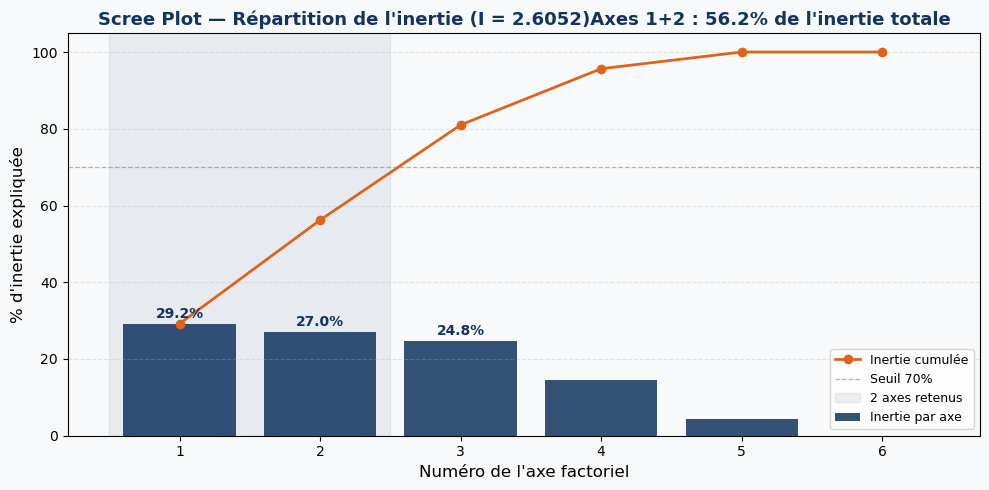

Axe 1 : 29.2%  |  Axe 2 : 27.0%  |  Total : 56.2%
 Représentation partielle — interpréter avec nuance.


In [50]:
# Calcul des pourcentages d'inertie expliquée par chaque axe
# valeurs_propres / inertie_totale = proportion de l'inertie sur cet axe
# × 100 = conversion en pourcentage
pct_inertie = (valeurs_propres / inertie_totale) * 100

# np.cumsum() : somme cumulée — pct_cumule[k] = % d'inertie expliqué par les axes 1 à k+1
pct_cumule  = np.cumsum(pct_inertie)

# On affiche au maximum 10 axes (inutile d'afficher des axes avec 0% d'inertie)
n_aff = min(10, len(sigma))

fig, ax = plt.subplots(figsize=(10, 5))  # fig = figure entière, ax = zone de dessin — (10, 5) = largeur × hauteur en pouces
fig.patch.set_facecolor('#F8F9FA')  # couleur de fond de la figure (autour du graphique)
ax.set_facecolor('#F8F9FA')         # couleur de fond de la zone de dessin

# ax.bar() trace un diagramme en barres
# range(1, n_aff + 1) : numéros des axes (1, 2, 3, ...)
# alpha=0.85 : légère transparence pour un rendu plus doux
ax.bar(range(1, n_aff + 1), pct_inertie[:n_aff],
       color=MARINE, alpha=0.85, label='Inertie par axe')

# ax.plot() trace une courbe — marker='o' ajoute un point à chaque axe
ax.plot(range(1, n_aff + 1), pct_cumule[:n_aff],
        color=ORANGE, marker='o', linewidth=2, label='Inertie cumulée')

# axhline() trace une ligne horizontale à y=70 — ligne de référence : 70% est un seuil acceptable
ax.axhline(70, color='gray', linestyle='--', linewidth=0.9, alpha=0.6, label='Seuil 70%')

# axvspan() colore une bande verticale entre x=0.5 et x=2.5 — met en évidence les 2 axes retenus
ax.axvspan(0.5, 2.5, alpha=0.07, color=MARINE, label='2 axes retenus')

# Annotation des 3 premiers axes : affiche le % d'inertie au-dessus de chaque barre
for k in range(min(3, n_aff)):
    ax.text(k + 1,                  # position x = numéro de l'axe
            pct_inertie[k] + 1.5,  # position y = légèrement au-dessus de la barre
            f'{pct_inertie[k]:.1f}%',  # texte affiché (1 décimale)
            ha='center', fontsize=10, fontweight='bold', color=MARINE)

ax.set_xlabel("Numéro de l'axe factoriel", fontsize=12)
ax.set_ylabel("% d'inertie expliquée", fontsize=12)
ax.set_title(f"Scree Plot — Répartition de l'inertie (I = {inertie_totale:.4f})"
    f"Axes 1+2 : {pct_cumule[1]:.1f}% de l'inertie totale",
    fontsize=13, fontweight='bold', color=MARINE
)
ax.set_xticks(range(1, n_aff + 1))  # force les graduations à être des entiers (1, 2, 3...)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.3)  # grille horizontale uniquement, en pointillés discrets
plt.tight_layout()  # ajuste automatiquement les marges pour éviter que les textes soient coupés
plt.savefig('../reports/figures/screeplot.png', dpi=150, bbox_inches='tight')  # sauvegarde en PNG haute résolution
plt.show()

print(f"Axe 1 : {pct_inertie[0]:.1f}%  |  Axe 2 : {pct_inertie[1]:.1f}%  |  Total : {pct_cumule[1]:.1f}%")
# Évaluation de la qualité de la représentation 2D
if pct_cumule[1] >= 70:
    print("Représentation 2D fiable — le biplot est interprétable.")
elif pct_cumule[1] >= 50:
    print(" Représentation partielle — interpréter avec nuance.")
else:
    print(" Moins de 50% — mentionner cette limite dans le rapport.")


### Comment lire ce graphique

On cherche le **coude** : le point où la courbe commence à s'aplatir.  
On retient les axes qui se trouvent avant ce coude.

Si les axes 1+2 captent moins que prévu, cela signifie que les différences entre domaines sont complexes et ne se résument pas facilement en deux dimensions.  

---
## Étape 10 — Qualité de représentation (cos²)

On a projeté des données complexes sur un plan 2D : on perd une partie de l'information.  
Le cos² mesure à quel point un point est **fidèlement représenté** sur les deux axes choisis.

$$\cos^2_i = \frac{F_{i,1}^2 + F_{i,2}^2}{\displaystyle\sum_{k=1}^{K} F_{i,k}^2}$$

Le **dénominateur** utilise **tous les axes** (pas seulement les 2 premiers).  
Si on utilisait seulement les 2 premiers, le cos² vaudrait toujours 1 par construction — ce qui ne mesurerait rien.

**Règle d'interprétation :**
- cos² ≥ 0.5 → point bien représenté → **position fiable sur le biplot**
- cos² < 0.5 → point mal représenté → **sa position en 2D peut être trompeuse**

In [46]:
SEUIL_COS2 = 0.5

# Cos² des domaines
# Dénominateur = distance carrée totale sur TOUS les axes
dist2_dom  = (coords_dom_all**2).sum(axis=1)
cos2_dom   = (coords_dom**2).sum(axis=1) / dist2_dom
cos2_dom_s = pd.Series(cos2_dom, index=contingence.index)

# Cos² des compétences
dist2_comp  = (coords_comp_all**2).sum(axis=1)
cos2_comp   = (coords_comp**2).sum(axis=1) / dist2_comp
cos2_comp_s = pd.Series(cos2_comp, index=contingence.columns)

# Affichage des domaines
print(f"{'Domaine':<28} {'Axe 1':>8} {'Axe 2':>8} {'cos²':>7}  Qualité")
print("─" * 65)
for i, nom in enumerate(contingence.index):
    q      = cos2_dom_s[nom]
    statut = 'Bon' if q >= SEUIL_COS2 else 'Prudence'
    print(f"{nom:<28} {coords_dom[i,0]:>+8.4f} {coords_dom[i,1]:>+8.4f} {q:>7.4f}  {statut}")

# Affichage des compétences
print()
print(f"{'Compétence':<30} {'Axe 1':>8} {'Axe 2':>8} {'cos²':>7}  Qualité")
print("─" * 68)
for j, nom in enumerate(contingence.columns):
    q      = cos2_comp_s[nom]
    statut = ' Bon' if q >= SEUIL_COS2 else 'Prudence'
    print(f"{nom:<30} {coords_comp[j,0]:>+8.4f} {coords_comp[j,1]:>+8.4f} {q:>7.4f}  {statut}")

Domaine                         Axe 1    Axe 2    cos²  Qualité
─────────────────────────────────────────────────────────────────
Commerce & Marketing          +1.0638  -0.8737  0.8137  Bon
Data & Analyse                -0.8257  +0.1083  0.2082  Prudence
Finance & Compta              +0.9937  +2.0011  0.9942  Bon
Gestion de Projet             -0.7201  -0.1152  0.2504  Prudence
RH & Recrutement              +0.6066  -0.9847  0.0975  Prudence
Tech & Ingénierie             -1.0677  +0.0792  0.4368  Prudence

Compétence                        Axe 1    Axe 2    cos²  Qualité
────────────────────────────────────────────────────────────────────
Accounting/Auditing             +1.1013  +2.3004  0.9903   Bon
Administrative                  +0.3873  -0.2451  0.0786  Prudence
Advertising                     +0.5830  -0.7192  0.8780   Bon
Analyst                         -0.5921  +0.4668  0.0952  Prudence
Art/Creative                    -0.5319  -0.0933  0.2596  Prudence
Business Development       

### Ce qu'on fait avec ces valeurs

Dans le biplot final, les points avec cos² < 0.5 seront affichés en **transparence**.  
Cela rappelle visuellement qu'ils ne doivent pas être commentés : leur position sur le graphique 2D ne reflète pas fidèlement leur vraie position dans l'espace.

Grâce aux domaines homogènes, on attend ici moins de points en transparence que dans la version précédente.

---
## Étape 11 — Contributions (CTR) et interprétation des axes

La contribution d'un point à un axe mesure dans quelle mesure ce point a **construit** cet axe.

$$CTR_{i,k} = \frac{r_i \cdot F_{i,k}^2}{\lambda_k}$$

La somme des CTR de tous les points vaut 100% pour chaque axe.

| Indicateur | Question posée | Usage |
|---|---|---|
| **Cos²** | Ce point est-il bien *représenté* en 2D ? | Filtrer ce qu'on peut interpréter |
| **CTR** | Ce point a-t-il *construit* l'axe ? | Comprendre et nommer les axes |

On lit les plus gros contributeurs de chaque côté de chaque axe, et on cherche ce qu'ils ont en commun pour donner un **nom à l'axe**.

In [47]:
# CTR des domaines sur les axes 1 et 2
ctr_dom_ax1  = (ri * coords_dom[:, 0]**2) / valeurs_propres[0]
ctr_dom_ax2  = (ri * coords_dom[:, 1]**2) / valeurs_propres[1]

# CTR des compétences sur les axes 1 et 2
ctr_comp_ax1 = (cj * coords_comp[:, 0]**2) / valeurs_propres[0]
ctr_comp_ax2 = (cj * coords_comp[:, 1]**2) / valeurs_propres[1]

def top_ctr(noms, ctr_vals, coords_ax, n_top=5, label=''):
    """Affiche les top contributeurs d'un axe avec leur signe."""
    paires = sorted(zip(range(len(ctr_vals)), ctr_vals), key=lambda x: x[1], reverse=True)
    print(f"  {label}")
    for k, ctr_val in paires[:n_top]:
        signe = '+' if coords_ax[k] > 0 else '−'
        print(f"    {signe} {noms[k]:<35} CTR = {ctr_val*100:5.1f}%  (coord = {coords_ax[k]:+.4f})")

print("═" * 62)
print(f"  AXE 1  ({pct_inertie[0]:.1f}% de l'inertie)")
print("═" * 62)
top_ctr(list(contingence.index),   ctr_dom_ax1,  coords_dom[:, 0],  label='Domaines :')
print()
top_ctr(list(contingence.columns), ctr_comp_ax1, coords_comp[:, 0], label='Compétences :')

print()
print("═" * 62)
print(f"  AXE 2  ({pct_inertie[1]:.1f}% de l'inertie)")
print("═" * 62)
top_ctr(list(contingence.index),   ctr_dom_ax2,  coords_dom[:, 1],  label='Domaines :')
print()
top_ctr(list(contingence.columns), ctr_comp_ax2, coords_comp[:, 1], label='Compétences :')

print()
print("═" * 62)
print(f"  Axe 1 ({pct_inertie[0]:.1f}%) : Compétences Commerciales & Financières ↔ Compétences Techniques & Analytiques")
print(f"  Axe 2 ({pct_inertie[1]:.1f}%) : Spécialisation Finance/Comptabilité ↔ Fonctions Commerciales/RH")

══════════════════════════════════════════════════════════════
  AXE 1  (29.2% de l'inertie)
══════════════════════════════════════════════════════════════
  Domaines :
    + Commerce & Marketing                CTR =  39.6%  (coord = +1.0638)
    − Tech & Ingénierie                   CTR =  27.1%  (coord = -1.0677)
    + Finance & Compta                    CTR =  18.7%  (coord = +0.9937)
    − Gestion de Projet                   CTR =  16.3%  (coord = -0.7201)
    − Data & Analyse                      CTR =  10.3%  (coord = -0.8257)

  Compétences :
    − Information Technology              CTR =  25.9%  (coord = -0.9704)
    + Sales                               CTR =  22.6%  (coord = +1.1339)
    + Business Development                CTR =  16.8%  (coord = +1.1055)
    − Engineering                         CTR =  15.9%  (coord = -1.1055)
    + Accounting/Auditing                 CTR =   9.6%  (coord = +1.1013)

══════════════════════════════════════════════════════════════
  AXE 2  (

### Comment nommer les axes

On regarde les domaines et compétences avec la CTR la plus élevée de chaque côté.  
On cherche ce qui les distingue et on donne un nom à cet axe.

**Exemple de raisonnement :**  
Si l'Axe 1 est construit par « Finance & Compta » (côté +) et « Tech & Ingénierie » (côté −),  
avec les compétences « Accounting » (côté +) et « Cloud Computing » (côté −),  
on peut l'appeler : *« Axe 1 : Gestion financière ↔ Technique informatique »*.

---
## Étape 12 — Biplot final

C'est le **résultat de toute l'analyse**. Toutes les étapes précédentes avaient un seul but : produire ce graphique.

### Règles de lecture

| Ce qu'on voit | Ce que ça signifie |
|---|---|
| Domaine **proche** d'une compétence | Cette compétence est sur-représentée dans ce domaine |
| Domaine **loin** d'une compétence | Peu ou pas de lien |
| Deux domaines **proches** | Profils de compétences similaires |
| Point **loin du centre** | Profil très original, associations fortes |
| Point **proche du centre** | Profil proche de la moyenne |

> **Important :** on n'interprète que les points avec cos² ≥ 0.5.  
> Les points transparents sont mal représentés en 2D — leur position peut être trompeuse.

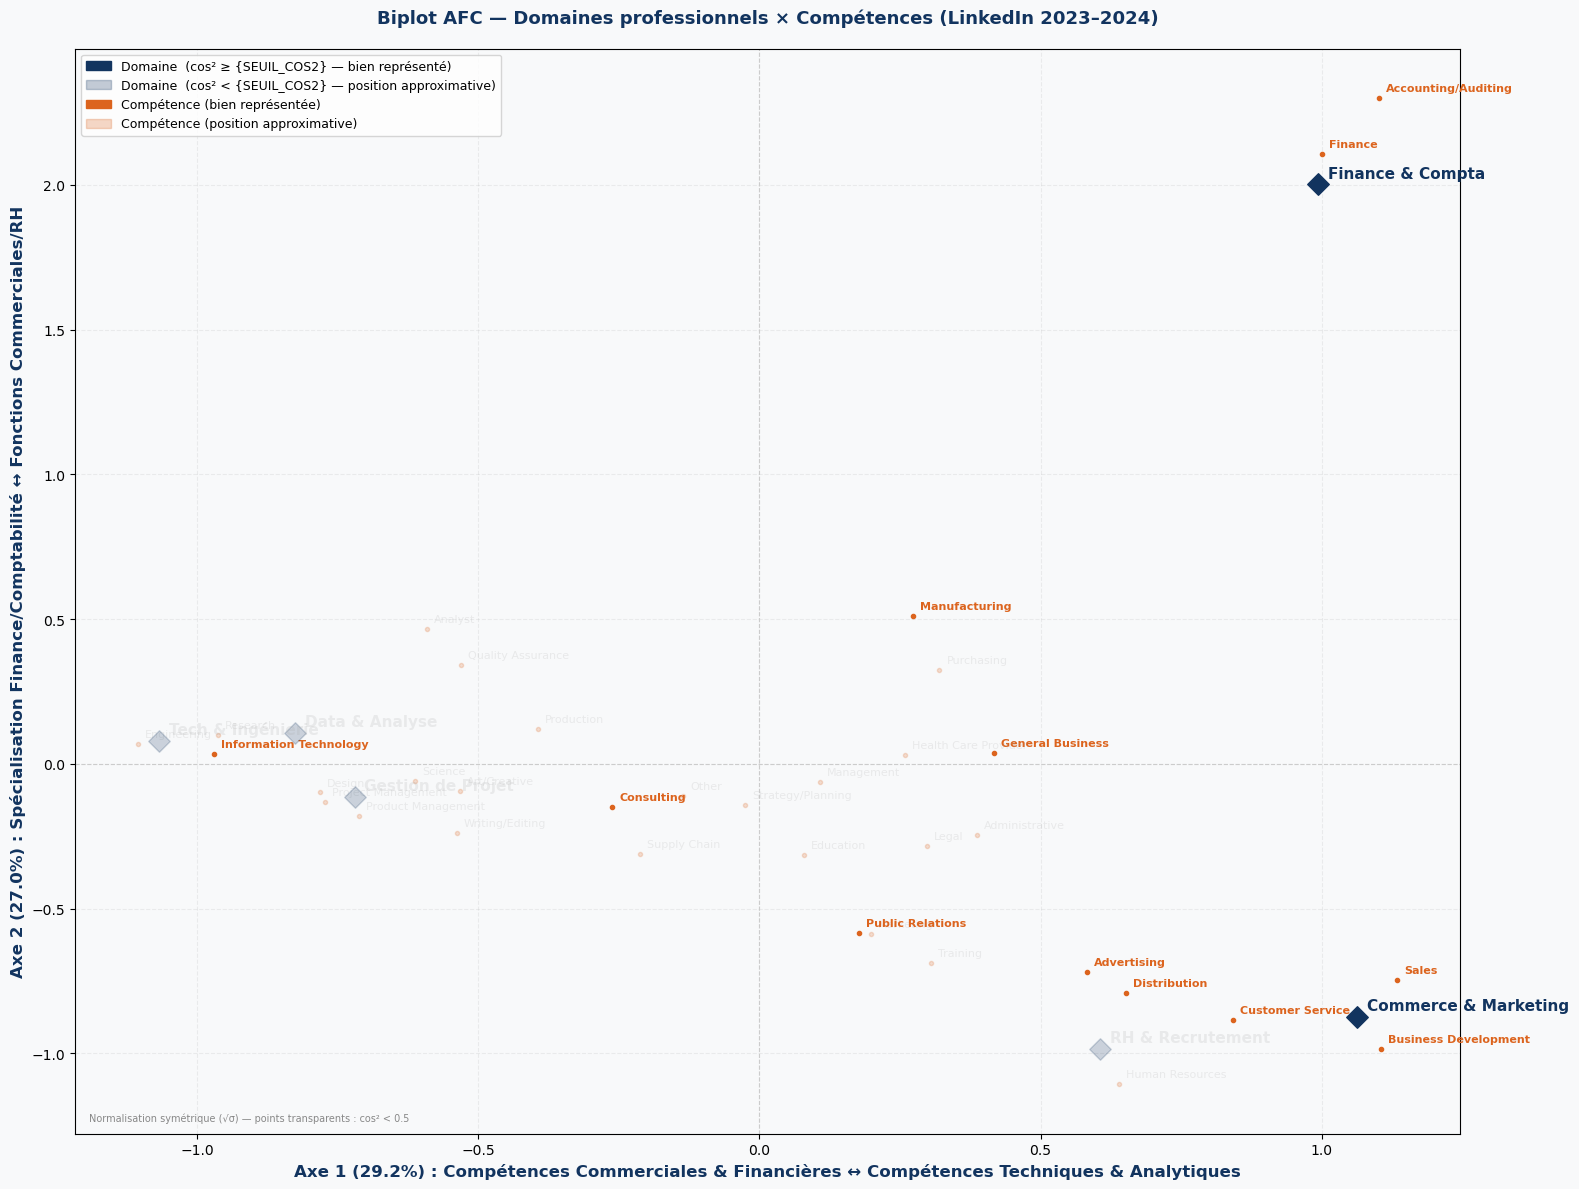

Graphique sauvegardé : biplot_afc.png


In [49]:
fig, ax = plt.subplots(figsize=(16, 12))  # grande figure pour que les étiquettes ne se chevauchent pas
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

# Axes de référence : lignes horizontale et verticale au centre du graphique
ax.axhline(0, color='#CCCCCC', linewidth=0.8, linestyle='--')  # axhline : ligne horizontale à y=0
ax.axvline(0, color='#CCCCCC', linewidth=0.8, linestyle='--')  # axvline : ligne verticale à x=0

# ── Compétences (cercles oranges) ──────────────────────────
for j, nom in enumerate(contingence.columns):  # on parcourt chaque compétence avec son indice
    x, y  = coords_comp[j, 0], coords_comp[j, 1]  # coordonnées sur Axe 1 et Axe 2
    bien  = cos2_comp_s[nom] >= SEUIL_COS2         # True si bien représentée, False sinon
    alpha = 1.0 if bien else 0.2  # 1.0 = opaque (visible), 0.2 = transparent (mal représenté)
    # ax.scatter() trace un point — s=9 = taille du point, zorder=4 = ordre d'empilement (plus grand = devant)
    ax.scatter(x, y, color=ORANGE, s=9, zorder=4, alpha=alpha, marker='o')
    # ax.annotate() ajoute une étiquette texte à côté d'un point
    # xytext=(5, 5) : décalage en pixels par rapport au point
    # textcoords='offset points' : interprète xytext en pixels
    ax.annotate(
        nom, (x, y),
        fontsize=8, color=ORANGE if bien else GRIS,
        fontweight='bold' if bien else 'normal',
        alpha=alpha, zorder=5,
        xytext=(5, 5), textcoords='offset points'
    )

# ── Domaines (losanges bleus) ──────────────────────────────
for i, nom in enumerate(contingence.index):  # même logique pour les domaines
    x, y  = coords_dom[i, 0], coords_dom[i, 1]
    bien  = cos2_dom_s[nom] >= SEUIL_COS2
    alpha = 1.0 if bien else 0.2
    # marker='D' : losange (diamond) — s=120 : plus grand que les compétences pour les distinguer
    ax.scatter(x, y, color=MARINE, s=120, zorder=6, alpha=alpha, marker='D')
    ax.annotate(
        nom, (x, y),
        fontsize=11, color=MARINE if bien else GRIS,
        fontweight='bold', alpha=alpha, zorder=7,
        xytext=(7, 5), textcoords='offset points'
    )

# ── Mise en forme du graphique ─────────────────────────────
ax.set_xlabel(f"Axe 1  ({{pct_inertie[0]:.1f}}% de l'inertie)",
              fontsize=12, color=MARINE, fontweight='bold')
ax.set_ylabel(f"Axe 2  ({{pct_inertie[1]:.1f}}% de l'inertie)",
              fontsize=12, color=MARINE, fontweight='bold')
ax.set_title(
    f"Biplot AFC — Domaines professionnels × Compétences (LinkedIn 2023–2024)",
    fontsize=13, fontweight='bold', color=MARINE, pad=18
)

# Update xlabel and ylabel to include interpreted axis names
ax.set_xlabel(f"Axe 1 ({pct_inertie[0]:.1f}%) : Compétences Commerciales & Financières ↔ Compétences Techniques & Analytiques", fontsize=12, color=MARINE, fontweight='bold')
ax.set_ylabel(f"Axe 2 ({pct_inertie[1]:.1f}%) : Spécialisation Finance/Comptabilité ↔ Fonctions Commerciales/RH", fontsize=12, color=MARINE, fontweight='bold')

# mpatches.Patch() crée un rectangle coloré pour la légende
# alpha=0.25 = transparent = représente les points mal représentés
legende = [
    mpatches.Patch(color=MARINE,             label=f'Domaine  (cos² ≥ {{SEUIL_COS2}} — bien représenté)'),
    mpatches.Patch(color=MARINE, alpha=0.25, label=f'Domaine  (cos² < {{SEUIL_COS2}} — position approximative)'),
    mpatches.Patch(color=ORANGE,             label='Compétence (bien représentée)'),
    mpatches.Patch(color=ORANGE, alpha=0.25, label='Compétence (position approximative)'),
]
ax.legend(handles=legende, loc='upper left', fontsize=9)  # handles= passe les éléments de légende manuels
ax.grid(True, linestyle='--', alpha=0.20)  # grille discrète sur les deux axes

# ax.text() avec transform=ax.transAxes : position en coordonnées relatives (0=gauche, 1=droite)
# (0.01, 0.01) = coin bas-gauche du graphique
ax.text(0.01, 0.01,
        "Normalisation symétrique (√σ) — points transparents : cos² < 0.5",
        transform=ax.transAxes, fontsize=7, color='#888888', va='bottom')

plt.tight_layout()
plt.savefig('../reports/figures/biplot_afc.png', dpi=150, bbox_inches='tight')  # sauvegarde haute résolution
plt.show()
print("Graphique sauvegardé : biplot_afc.png")


### Grille de lecture du biplot

Pour rédiger le commentaire, on suit cette structure en 5 points :

**1. Fiabilité du graphique**  
Indiquer le pourcentage d'inertie cumulé sur les axes 1+2.  
Si c'est > 70%, le graphique représente bien la réalité. Si c'est entre 50% et 70%, la représentation est partielle.

**2. Nommer les axes**  
À partir des contributions (Étape 11), donner un nom à chaque axe.  
Ex : *« L'Axe 1 oppose les compétences financières aux compétences techniques »*.

**3. Lire les associations domaine–compétence**  
Pour chaque domaine bien représenté (cos² ≥ 0.5), nommer les compétences proches et expliquer pourquoi cette association est logique.

**4. Lire les oppositions**  
Les domaines à l'opposé sur l'Axe 1 ont des profils très différents. Décrire cette opposition.

**5. Mentionner les limites**  
Signaler les domaines transparents (cos² < 0.5) et ne pas les interpréter.

---
## Étape 13 — Résumé et limites

### Résultats de l'analyse

| Paramètre | Valeur |
|---|---|
| Domaines analysés | 6 |
| Compétences retenues | *voir tableau de contingence* |
| Observations totales (n) | *voir étape 3* |
| χ² | *voir étape 6* |
| p-value | *voir étape 6* |
| Inertie totale I | *voir étape 6* |
| Inertie Axe 1 | *voir étape 9* |
| Inertie Axe 2 | *voir étape 9* |
| Inertie cumulée Axes 1+2 | *voir étape 9* |

### Qualité de représentation des domaines

| Domaine | cos² | Interprétation |
|---|---|---|
| Tech & Ingénierie | *voir étape 10* | OK ou NON |
| Data & Analyse | *voir étape 10* | OK ou NON |
| Gestion de Projet | *voir étape 10* | OK ou NON |
| Commerce & Marketing | *voir étape 10* | OK ou NON |
| Finance & Compta | *voir étape 10* | OK ou NON |
| RH & Recrutement | *voir étape 10* | OK ou NON |

> OK cos² ≥ 0.5 → position fiable sur le biplot, on peut interpréter.  
> NON cos² < 0.5 → position approximative, ne pas interpréter.

### Limites spécifiques à cette analyse

1. **Mapping manuel** : le regroupement en domaines est basé sur des mots-clés. Certains titres peuvent appartenir à plusieurs domaines à la fois — le premier mot-clé trouvé gagne, ce qui peut créer des erreurs de classification.

2. **Compétences trop larges** : les compétences dans `skills.csv` sont des catégories générales (ex : *Finance*, *Engineering*). Des données plus précises (ex : *Python*, *SQL*, *AWS*) donneraient un biplot avec des associations plus fines.

3. **Représentation partielle** : si les axes 1+2 capturent moins de 70% de l'inertie, une partie des associations n'est pas visible sur le graphique 2D. Il faut le mentionner dans le commentaire.

### Limites générales de l'AFC

**1. L'AFC est une méthode descriptive, pas explicative.**  
Elle montre qu'une compétence est souvent associée à un domaine, mais elle ne dit pas *pourquoi*. Une association forte sur le biplot peut avoir plusieurs explications différentes — l'AFC ne permet pas de choisir entre elles.

**2. L'AFC ne fonctionne que sur deux variables qualitatives à la fois.**  
On ne peut croiser qu'une variable en ligne et une variable en colonne. Si on veut analyser plus de deux variables simultanément (ex : domaine, compétence, pays, niveau d'expérience), il faut utiliser l'**ACM** (Analyse des Correspondances Multiples), qui est une généralisation de l'AFC.

**3. Les résultats dépendent fortement du découpage des modalités.**  
Regrouper différemment les postes ou choisir d'autres compétences peut changer la position des points sur le biplot. Il n'existe pas de découpage "objectif" : c'est une décision humaine qui influence les résultats.

**4. Les effectifs faibles rendent les résultats instables.**  
Une modalité avec peu d'observations (moins de 50–100) a un profil statistiquement fragile : un petit changement dans les données peut déplacer beaucoup son point sur le biplot. L'AFC est fiable seulement si chaque case du tableau de contingence est suffisamment remplie.

**5. L'AFC est sensible aux valeurs extrêmes.**  
Une modalité avec un profil très différent de toutes les autres (ex : infirmier dans un tableau de métiers tech) va monopoliser les premiers axes. Elle capture une grande part de l'inertie, et les différences entre les autres modalités deviennent invisibles. C'est pourquoi on a exclu les métiers hétérogènes dans cette analyse.

**6. Le biplot 2D est une approximation.**  
On projette un espace à $K = \min(I-1, J-1)$ dimensions sur un plan. Si $K > 2$, une partie de l'information est perdue. Le cos² indique pour chaque point quelle part de sa vraie position est visible en 2D — mais le lecteur du biplot ne voit que le résultat final, pas cette perte d'information, ce qui peut conduire à des lectures trop confiantes.

**7. L'AFC ne mesure pas la significativité des associations individuelles.**  
Le test du χ² dit si le tableau dans son ensemble montre un lien. Mais il ne dit pas si l'association entre *un domaine précis* et *une compétence précise* est statistiquement significative. On ne peut pas conclure sur un couple isolé avec la même certitude qu'on le ferait avec un test ciblé.